In [6]:
import os
import torch
import numpy as np
from extract import extract_graph, extract_die_area, load_file_content
import scipy.sparse as sp 
from helper import normalize_features, build_X_hop_mask , get_compressed_graph , relative_masking , load_cts_parameters
import pandas as pd

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
base_dir = "dataset_with_def/placement_files/"
csv_dir = "dataset_with_def/"



In [ ]:
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F

class FirstTerm(nn.Module):
    def __init__(self, num_cell_types, num_of_clusters , embedding_dim=8):
        super().__init__()
        self.cell_embedding = nn.Embedding(num_cell_types, embedding_dim)
        # Initialize 10.9M weights (The Dials)
        feature_dim = 18 + embedding_dim
        self.edge_mlp = nn.Sequential(
            nn.Linear(feature_dim*2, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

        nn.init.normal_(self.edge_mlp[2].weight, mean=0.0, std=0.001)
        nn.init.constant_(self.edge_mlp[2].bias, 0.01)


        # 3. THE CLUSTER HEAD (The C-Matrix Generator)
        # This replaces the N x K parameter bottleneck.
        self.cluster_head = nn.Sequential(
            nn.Linear(18 + embedding_dim, 64), 
            nn.ReLU(),
            nn.Linear(64, num_of_clusters)      # Output is K clusters
        )



    def forward(self, X, X_cell_ids, num_nodes, p_indices, A_skip_csr, current_k, tau=1.0):
        
        X_cell_ids = X_cell_ids.squeeze()
        cell_features = self.cell_embedding(X_cell_ids)  # Shape: [num_nodes, embedding_dim]
        X_combined = torch.cat([X, cell_features], dim=1)  # Shape: [num_nodes, 18 + embedding_dim]

        src_features = X_combined[p_indices[0]]  # Shape: [num_edges, feature_dim]
        dst_features = X_combined[p_indices[1]]  # Shape: [num_edges, feature_dim]
        edge_inputs = torch.cat([src_features, dst_features], dim=1)  # Shape: [num_edges, feature_dim*2]

        dynamic_p_weights = self.edge_mlp(edge_inputs).squeeze(-1)
        safe_weights = F.softplus(dynamic_p_weights) 


        # Enforce P >= 0 and build sparse matrix
        P = torch.sparse_coo_tensor(p_indices, safe_weights, 
                                    (num_nodes, num_nodes)).coalesce()
        
        # Reconstruction: XP
        X_hat = torch.sparse.mm(P, X)
        
        # Loss: ||X - XP||
        error = X - X_hat
        loss1 = torch.mean(error**2)   

        # Pass all node features through the head
        logits = self.cluster_head(X_combined) # Shape: [n, k]

        logits = logits[:, :current_k]
        
        #TERM2
        #C matrix with probability distribution across clusters for each node
        C = F.gumbel_softmax(logits, tau=tau, hard=False) # Shape: [n, k]
        # C = F.softmax(logits, dim=-1)  # Ensure positivity for SDDMM

        p_vals = P.values()
        
        # 1. Sum across rows (dim=1) to get the total weight leaving each node
        row_sums = torch.sparse.sum(P, dim=1).to_dense()
        
        # 2. Expand row_sums to match the non-zero values 
        # P.indices()[0] contains the row index for every specific edge
        p_vals_norm = p_vals / (row_sums[P.indices()[0]] + 1e-8)
        
        # Rebuild using the exact same sorted indices
        P_norm = torch.sparse_coo_tensor(P.indices(), p_vals_norm, 
                                         (num_nodes, num_nodes)).coalesce()
        
        # 2. Convert to CSR format (Required for the CUDA SDDMM engine)
        P_csr = P_norm.to_sparse_csr()
        
        # 3. SDDMM Magic! 
        # beta=1.0, alpha=-1.0 calculates exactly: (1.0 * P_csr) - (1.0 * C @ C^T)
        # It ONLY calculates this at the 10.9M non-zero locations!
        diff_csr = torch.sparse.sampled_addmm(P_csr, C, C.t(), beta=1.0, alpha=-1.0)
        
        # 4. Square the differences and sum them
        loss2 = torch.sum(diff_csr.values() ** 2)


        #TERM3
        M = torch.matmul(C.t(), torch.sparse.mm(A_skip_csr, C))  # [k, n] @ [n, n] @ [n, k] -> [k, k]
        # 2. Normalize M into a probability distribution (M_tilde)
        M = torch.clamp(M, min=0)
        M_tilde = M / (M.sum() + 1e-8)
        loss3 = -torch.sum(M_tilde * torch.log(M_tilde + 1e-8))

        # 3. Calculate Shannon Entropy: -sum(p * log(p))
        # We only calculate for non-zero entries to avoid log(0)
        # loss3 = torch.sum(M_tilde * torch.log(M_tilde + 1e-8))

        

        alpha_1 = 1.0 
        alpha_2 = 1.0    
        alpha_3 = 1.0    
        loss = alpha_1* loss1 + (alpha_2 * loss2) +(alpha_3 * loss3) 


        return  loss, loss1 , loss2, loss3,  C , X_combined

import math
def get_tau(epoch, total_epochs=301):
    tau_start = 2.0
    tau_end = 0.05  # Lower end-point to force high confidence
    
    # We want the "inflection point" (the steepest drop) around epoch 80-90
    # so that by epoch 120, the model has fully crystallized.
    center = 85 
    steepness = 0.12 # Controls how fast the drop is
    
    # Sigmoid decay formula
    current_tau = tau_end + (tau_start - tau_end) / (1 + math.exp(steepness * (epoch - center)))
    
    return current_tau


In [8]:
#Graph Neural Network Inference on the compressed graph (X_tilde, A_tilde_skip) 

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GraphConv, to_hetero , global_mean_pool

# ==========================================
# 1. The Base Homogeneous SAGE Model
# ==========================================
class BaseSAGE(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        # Using (-1, -1) leverages PyG's lazy initialization 
        self.conv1 = GraphConv((-1, -1), hidden_dim)
        self.conv2 = GraphConv((-1, -1), hidden_dim)

    def forward(self, x, edge_index, edge_weight=None):
        x = F.elu(self.conv1(x, edge_index, edge_weight))
        x = F.elu(self.conv2(x, edge_index, edge_weight))
        return x

class HeteroCTS_GNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_params):
        super().__init__()
        
        # 1. Define the Heterogeneous Schema explicitly
        self.metadata = (
            ['supernode'], 
            [
                ('supernode', 'physical', 'supernode'), 
                ('supernode', 'timing', 'supernode')
            ]
        )
        
        # 2. Initial projection to get raw features into hidden_dim space
        self.proj = nn.Linear(input_dim, hidden_dim)
        
        # 3. Create the Heterogeneous GNN
        # 'sum' aggregation combines the messages from physical and timing paths at each node
        self.gnn = to_hetero(BaseSAGE(hidden_dim), self.metadata, aggr='sum')
        
        # 4. Task Heads 
        self.power_head = nn.Sequential(
            nn.Linear(hidden_dim + num_params, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )
        
        # Wirelength: Expects mean + variance concatenated (size: 2 * hidden_dim)
        self.wl_head = nn.Sequential(
            nn.Linear(hidden_dim * 2 + num_params, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
        
        # Skew: Placeholder for Attention Pooling (Currently using Mean)
        self.skew_attn = nn.Linear(hidden_dim, 1) # Attention weights
        self.skew_head = nn.Sequential(
            nn.Linear(hidden_dim + num_params, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )


    def forward(self, x_dict, edge_index_dict,cts_params, edge_weight_dict=None):
        # Initial projection and GNN message passing
        x = {key: self.proj(feat) for key, feat in x_dict.items()}
        h_dict = self.gnn(x, edge_index_dict, edge_weight_dict)
        h = h_dict['supernode'] # [K, hidden_dim]

        # 2. Power: Mean Pool and Concatenate Knobs
        h_power = torch.mean(h, dim=0, keepdim=True) # [1, hidden_dim]
        h_power_combined = torch.cat([h_power, cts_params], dim=-1)
        power_pred = self.power_head(h_power_combined)

        # 3. Wirelength: Mean + Var Pool and Concatenate Knobs [cite: 198, 199]
        mu = h.mean(dim=0, keepdim=True)
        var = h.var(dim=0, keepdim=True)
        h_wl_combined = torch.cat([mu, var, cts_params], dim=-1)
        wl_pred = self.wl_head(h_wl_combined)

        # 4. Skew: Attention Pool and Concatenate Knobs [cite: 190, 191]
        attn_scores = F.softmax(self.skew_attn(h), dim=0)
        h_skew = torch.sum(attn_scores * h, dim=0, keepdim=True)
        h_skew_combined = torch.cat([h_skew, cts_params], dim=-1)
        skew_pred = self.skew_head(h_skew_combined)

        return skew_pred, power_pred, wl_pred
    
 

In [9]:
from helper import relative_masking
import random , os
from helper import normalize_features, build_X_hop_mask , get_compressed_graph , relative_masking , load_cts_parameters

# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# according to number of your cts knobs
NUM_CTS_KNOBS = 4 
metadata = torch.load("global_metadata.pt")
global_max_cell_types = metadata['global_max_cell_types']
global_max_k = metadata['global_max_k']

model = FirstTerm(num_cell_types=global_max_cell_types, num_of_clusters=global_max_k).to(device)
gnn_model = HeteroCTS_GNN(input_dim=28, hidden_dim=64, num_params=NUM_CTS_KNOBS).to(device)

# FIXED: Optimizer now tracks BOTH models for Joint Optimization 
optimizer = optim.Adam(list(model.parameters()) + list(gnn_model.parameters()), lr=0.01)

processed_dir = "processed_graphs"
# List all processed file names
design_files = [f for f in os.listdir(processed_dir) if f.endswith('.pt')]


for epoch in range(301):
    
    current_tau = get_tau(epoch)
    
    # Added confidence tracker
    total_l, l1_sum, l2_sum, l3_sum, conf_sum = 0, 0, 0, 0, 0
    total_task_loss, total_skew_l, total_power_l, total_wl_l = 0, 0, 0, 0 
    
    for i, filename in enumerate(design_files):
        data = torch.load(os.path.join(processed_dir, filename))
        optimizer.zero_grad()

        # 3. TRANSFER: Move ONLY what you need to the GPU
        X = data['X'].to(device)
        X_cell_ids = data['X_cell_ids'].to(device)
        p_indices = data['p_indices'].to(device)
        A_skip_csr = data['A_skip_csr'].to(device)
        A_wire_csr = data['A_wire_csr'].to(device)


        loss, l1, l2, l3, C , X_combined = model(
            X, 
            X_cell_ids,
            data['num_nodes'], 
            p_indices, 
            A_skip_csr,
            data['current_k'],
            tau=current_tau
        )

        X_tilde, A_tilde_skip , A_wire = get_compressed_graph(X_combined, C, A_skip_csr, A_wire_csr)

        if epoch == 0:
            print(X_tilde.shape)



        if epoch >= 100: # (Or whenever your GNN phase starts)
            
            # Instantly get PyG-ready tensors
            wire_edge_index, wire_edge_weight = relative_masking(A_wire, threshold=0.10)
            skip_edge_index, skip_edge_weight = relative_masking(A_tilde_skip, threshold=0.10)

            
            # Print the exact wire counts
            # print(f"Surviving Wires: {wire_edge_weight.size(0)}")
            # print(f"Surviving Skips: {skip_edge_weight.size(0)}")

            x_dict = {'supernode': X_tilde}
            edge_index_dict = {
                ('supernode', 'physical', 'supernode'): wire_edge_index,
                ('supernode', 'timing', 'supernode'): skip_edge_index
            }
            edge_weight_dict = {
                ('supernode', 'physical', 'supernode'): wire_edge_weight,
                ('supernode', 'timing', 'supernode'): skip_edge_weight
            }

            run = random.choice(data['cts_runs'])

            
            # --- CLEAN DEBUG PRINT ---
            d_name = data['run_folder']
            t_skew = run['targets']['skew'].item()
            t_power = run['targets']['power'].item()
            t_wl = run['targets']['wl'].item()
            # print(f"--> [DEBUG] Design: {d_name} | Target Skew: {t_skew:.4f} | Power: {t_power:.4f} | WL: {t_wl:.4f}")
            
            
            # 1 Forward Pass instead of 10
            skew_p, power_p, wl_p = gnn_model(x_dict, edge_index_dict, run['knobs'].view(1, -1), edge_weight_dict)
            
            l_skew = F.mse_loss(skew_p, run['targets']['skew'].view(1, -1).to(device))
            l_power = F.mse_loss(power_p, run['targets']['power'].view(1, -1).to(device))
            l_wl = F.mse_loss(wl_p, run['targets']['wl'].view(1, -1).to(device))
            
            design_task_loss = l_skew + l_power + l_wl
            
            # Track the metrics directly (No need to divide by num_runs anymore)
            total_task_loss += design_task_loss.item()
            total_skew_l += l_skew.item()
            total_power_l += l_power.item()
            total_wl_l += l_wl.item()
            
            # JOINT OPTIMIZATION: Now mathematically safe for the GPU
            joint_loss = loss + design_task_loss
            joint_loss.backward()
        else:
            # If epoch < 100, only train the clustering model
            loss.backward()

        optimizer.step()

        total_l += loss.item()
        l1_sum += l1.item()
        l2_sum += l2.item()
        l3_sum += l3.item()
        
        # Calculate Average Confidence:
        # C.max(dim=1)[0] gives the probability of the most likely cluster for each node.
        # We take the mean across all nodes in the design.
        with torch.no_grad():
            avg_node_conf = C.max(dim=1)[0].mean().item()
            conf_sum += avg_node_conf

        del X, X_cell_ids, p_indices, A_skip_csr, A_wire_csr, C, data, X_tilde, X_combined
        if i % 10 == 0:
            torch.cuda.empty_cache()

    
    
# ----------------------------------------
    # CORRECTED LOGGING BLOCK
    # ----------------------------------------
    if epoch % 10 == 0:
        n = len(design_files)
        log_str = (f"Epoch {epoch:3} | Base Loss: {total_l/n:.4f} | "
                   f"L1: {l1_sum/n:.4f} | L2: {l2_sum/n:.4f} | L3: {l3_sum/n:.4f} | "
                   f"Conf: {(conf_sum/n)*100:.2f}%")
                   
        # Match this to whatever epoch your GNN starts training! (Currently 0 for your debug)
        if epoch >= 0:  
            log_str += (f"\n          | Total Task: {total_task_loss/n:.4f} -> "
                        f"[Skew: {total_skew_l/n:.4f} | Power: {total_power_l/n:.4f} | WL: {total_wl_l/n:.4f}]")
                        
        # Indented INSIDE the if epoch % 10 == 0 block
        print(log_str)

torch.Size([1000, 28])
torch.Size([798, 28])
torch.Size([798, 28])
torch.Size([798, 28])
Epoch   0 | Base Loss: 18010.7512 | L1: 17956.2717 | L2: 41.1857 | L3: 13.2940 | Conf: 3.39%
          | Total Task: 0.0000 -> [Skew: 0.0000 | Power: 0.0000 | WL: 0.0000]
Epoch  10 | Base Loss: 103.2145 | L1: 2.9304 | L2: 88.3863 | L3: 11.8978 | Conf: 6.90%
          | Total Task: 0.0000 -> [Skew: 0.0000 | Power: 0.0000 | WL: 0.0000]
Epoch  20 | Base Loss: 64.6647 | L1: 1.7729 | L2: 51.4385 | L3: 11.4532 | Conf: 7.50%
          | Total Task: 0.0000 -> [Skew: 0.0000 | Power: 0.0000 | WL: 0.0000]
Epoch  30 | Base Loss: 52.4807 | L1: 1.5424 | L2: 39.8793 | L3: 11.0589 | Conf: 7.55%
          | Total Task: 0.0000 -> [Skew: 0.0000 | Power: 0.0000 | WL: 0.0000]
Epoch  40 | Base Loss: 46.4137 | L1: 1.3840 | L2: 34.1315 | L3: 10.8982 | Conf: 7.69%
          | Total Task: 0.0000 -> [Skew: 0.0000 | Power: 0.0000 | WL: 0.0000]
Epoch  50 | Base Loss: 43.1496 | L1: 1.2817 | L2: 31.1489 | L3: 10.7190 | Conf: 7.8

KeyboardInterrupt: 

Visualizing Top 10 Clusters: [ 759  704 1227 1283  519 1019  654   68  420  818]
Sizes of Top 10 Clusters: [379 276 186 167 163 147 141 132 121 120]


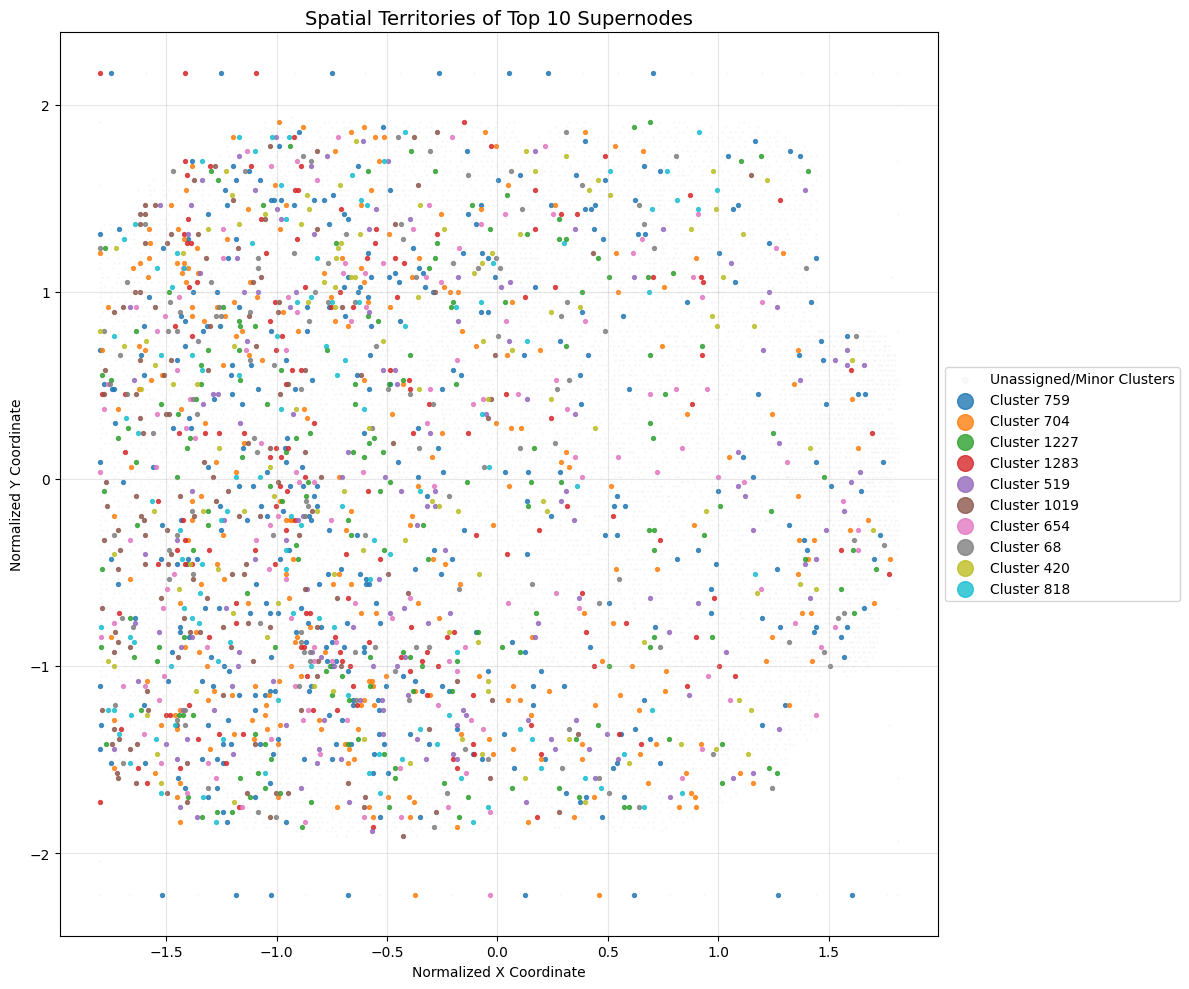

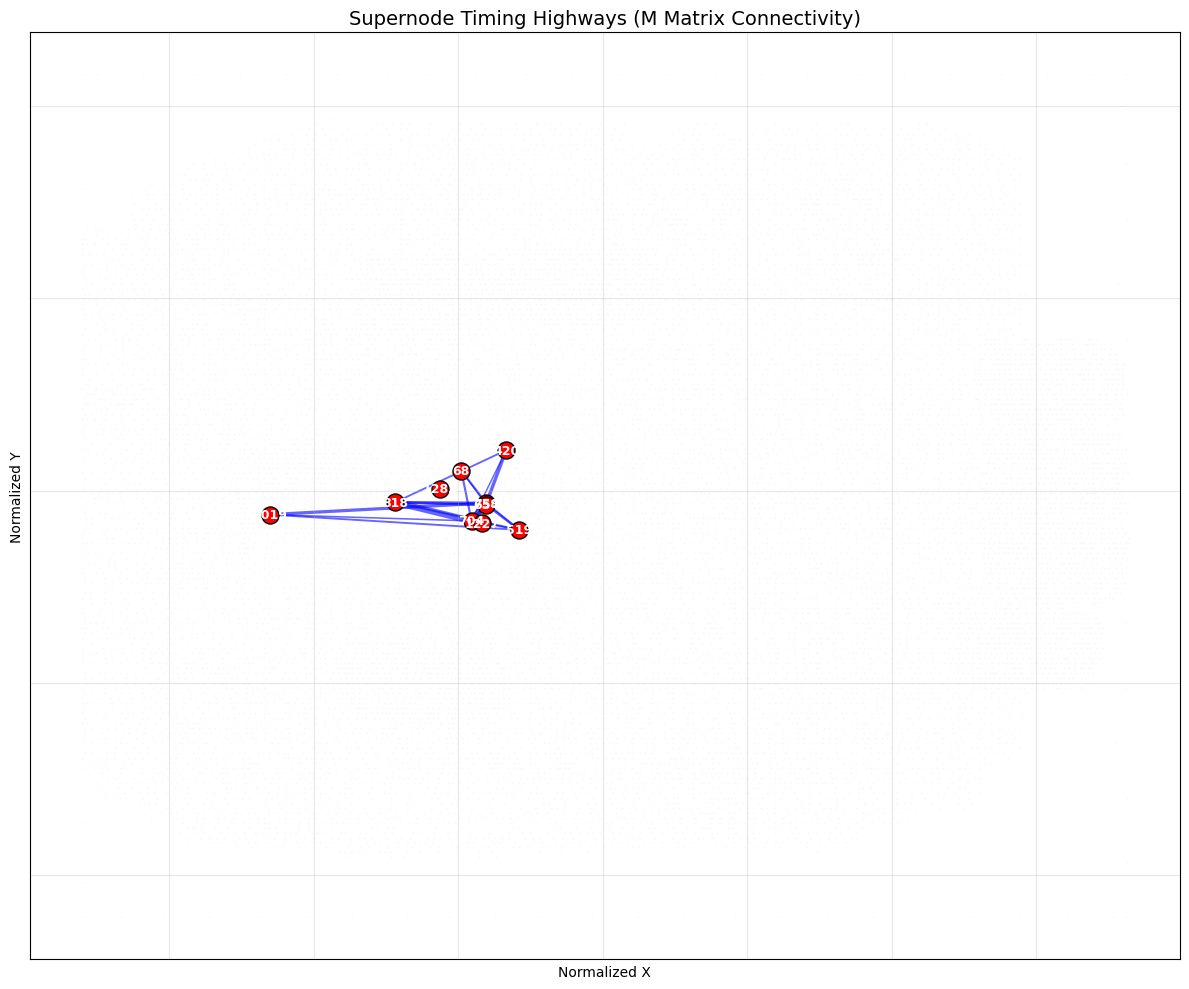

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import torch

# --- 0. RECALCULATE M (The Missing Step) ---
# We use the final 'C' from your training loop and your 'A_skip_csr'
with torch.no_grad():
    A_skip_gpu = A_skip_csr.to(C.device) 
    M_tensor = torch.matmul(C.t(), torch.sparse.mm(A_skip_gpu, C))
    M_dense = M_tensor.cpu().numpy()


# --- 1. Extract Data from Tensors ---
# Get the "hard" cluster assignment for each node by finding the max probability
C_probs = C.detach().cpu().numpy()
hard_assignments = np.argmax(C_probs, axis=1)

# Extract X and Y coordinates (columns 0 and 1 in your X_float)
x_coords = X_float[:, 0].cpu().numpy()
y_coords = X_float[:, 1].cpu().numpy()

# --- 2. Identify the Top Clusters ---
# Count how many nodes belong to each cluster
unique_clusters, counts = np.unique(hard_assignments, return_counts=True)

# Sort to find the indices of the largest clusters
top_cluster_indices = np.argsort(-counts)[:10]
top_clusters = unique_clusters[top_cluster_indices]

print(f"Visualizing Top 10 Clusters: {top_clusters}")
print(f"Sizes of Top 10 Clusters: {counts[top_cluster_indices]}")

# =========================================================
# PLOT 1: SPATIAL TERRITORIES (The Physical Layout)
# =========================================================
plt.figure(figsize=(12, 10))

# 1. Plot all gates as faint gray background noise
plt.scatter(x_coords, y_coords, s=1, c='lightgray', alpha=0.1, label='Unassigned/Minor Clusters')

# 2. Plot the top 10 clusters in distinct colors
cmap = plt.get_cmap('tab10')
for i, cluster_id in enumerate(top_clusters):
    # Create a boolean mask for nodes in this specific cluster
    mask = (hard_assignments == cluster_id)
    plt.scatter(x_coords[mask], y_coords[mask], s=8, color=cmap(i), alpha=0.8, label=f'Cluster {cluster_id}')

plt.title("Spatial Territories of Top 10 Supernodes", fontsize=14)
plt.xlabel("Normalized X Coordinate")
plt.ylabel("Normalized Y Coordinate")
# Increase marker size in legend so it's readable
plt.legend(markerscale=4, loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================
# PLOT 2: SUPERNODE CONNECTIVITY (The Timing Highways)
# =========================================================
plt.figure(figsize=(12, 10))

# Plot the faint background map again for spatial context
plt.scatter(x_coords, y_coords, s=1, c='lightgray', alpha=0.05)

# Build a NetworkX graph to draw the connections
G = nx.Graph()
pos = {} # Dictionary to store the (x,y) center of each supernode

# 1. Calculate the spatial centroid of each top cluster
for cluster_id in top_clusters:
    mask = (hard_assignments == cluster_id)
    # The centroid is the average X and Y of all gates in the cluster
    centroid_x = np.mean(x_coords[mask])
    centroid_y = np.mean(y_coords[mask])
    
    pos[cluster_id] = (centroid_x, centroid_y)
    G.add_node(cluster_id)

# 2. Add edges based on the M matrix (Timing Connections)
# We calculate a threshold so we only draw the most important "highways"
sub_M = M_dense[np.ix_(top_clusters, top_clusters)]
# If all values are 0 (no timing connections between top 10), avoid threshold error
if sub_M.max() > 0:
    threshold = np.percentile(sub_M[sub_M > 0], 50) # Only keep top 50% of connections
    
    for i in top_clusters:
        for j in top_clusters:
            if i < j: # Prevent drawing duplicate undirected edges
                weight = M_dense[i, j]
                if weight > threshold:
                    G.add_edge(i, j, weight=weight)

# 3. Draw the Graph
edges = G.edges(data=True)
if len(edges) > 0:
    # Scale the line thickness based on how strong the M matrix connection is
    max_weight = max([d['weight'] for u, v, d in edges])
    edge_widths = [(d['weight'] / max_weight) * 5 for u, v, d in edges] 

    nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color='blue', alpha=0.6)

nx.draw_networkx_nodes(G, pos, node_color='red', node_size=150, edgecolors='black')
nx.draw_networkx_labels(G, pos, font_size=9, font_color='white', font_weight='bold')

plt.title("Supernode Timing Highways (M Matrix Connectivity)", fontsize=14)
plt.xlabel("Normalized X")
plt.ylabel("Normalized Y")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# C[1] is the row for node 1 (size [num_clusters])
max_index = torch.argmax(C[1])
print(C[2].max())
print(max_index)

max_index2 = torch.argmax(C[2])
print(max_index2)

tensor(0.3417, device='cuda:0', grad_fn=<MaxBackward1>)
tensor(759, device='cuda:0')
tensor(704, device='cuda:0')
